# Flare

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## download


In [2]:
 /bin/rm -rf 1838 1712
 download_chandra_obsid 1838,1712


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  294.2 kb/s
  oif      fits       23 Kb  ####################          < 1 s  311.9 kb/s
  vv       pdf        33 Kb  ####################          < 1 s  693.6 kb/s
  cntr_img fits       75 Kb  ####################          < 1 s  6954.7 kb/s
  cntr_img jpg       446 Kb  ####################          < 1 s  5868.6 kb/s
  evt2     fits        3 Mb  ####################          < 1 s  21671.8 kb/s
  full_img fits       48 Kb  ####################          < 1 s  4881.3 kb/s
  full_img jpg        47 Kb  ####################          < 1 s  4845.0 kb/s
  bpix     fits       12 Kb  ####################          < 1 s  804.1 kb/s
  fov      fits        6 Kb  ####################          < 1 s  780.4 kb/s
  eph1     fits      281 Kb  ####################          < 1 s  5

In [3]:
chandra_repro 1838,1712 out= 



Processing input directory '/data/sdsreg/thread_output/CIAO4.9/flare/1838'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/flare/1838/repro/acisf01838_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...

Cleaning up intermediate files

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9/flare/1838/repro


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/flare/1712'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create 

In [4]:
dmcopy "1838/repro/acisf01838_repro_evt2.fits[energy=500:7000,ccd_id=7]" 1838_c7.fits clob+


## Remove bright soures

In [5]:
apply_fov_limits 1838_c7.fits out=1838_c7.img \
    fov=1838/repro/acisf01838_repro_fov1.fits \
    bin=1 mode=h clob+

Running: apply_fov_limits
  version: 12 September 2016
Observation: ObsId 1838 - ACIS-012367
Using ccd_id=7 from 1838_c7.fits
Using FOV file 1838/repro/acisf01838_repro_fov1.fits.

The output image will have 1110 by 1109 pixels, pixel size of 0.492 arcsec,
    and cover x=3638.5:4748.5:1,y=3844.5:4953.5:1.

Created: 1838_c7.img


In [6]:
vtpdetect 1838_c7.img out=1838_vtp.src mode=h clob+ scale=0.2
dmcopy 1838_vtp.src"[src_region][shape=Polygon]" vtp.reg clob+

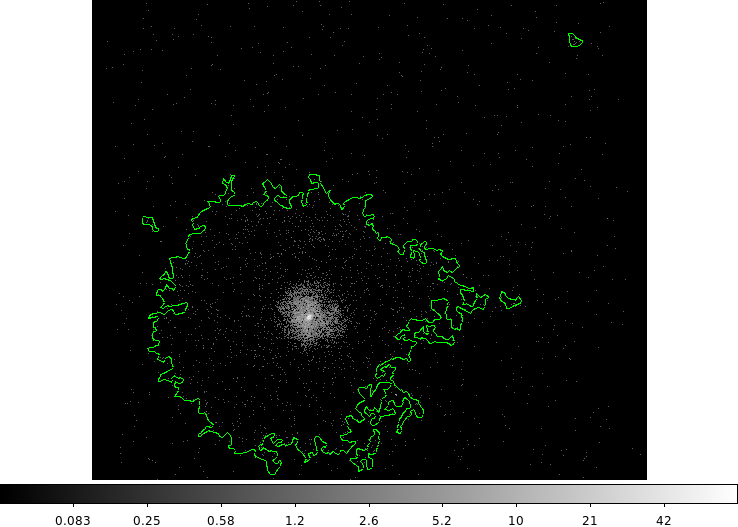

In [7]:
ds9 1838_c7.img -region vtp.reg -scale log -zoom 0.5 \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

In [8]:
dmcopy "1838_c7.fits[exclude sky=region(vtp.reg)]" 1838_c7_bg.fits clob+

## Create the lightcurve

In [9]:
dmlist 1838_c7_bg.fits"[GTI7]" data

 
--------------------------------------------------------------------------------
Data for Table Block GTI7
--------------------------------------------------------------------------------
 
ROW    START                STOP
 
     1  84245785.9481317699  84253742.5989308059


In [10]:
pset dmextract infile="1838_c7_bg.fits[bin time=84245789.155:84253741.155:259.28]"
pset dmextract outfile=1838_c7_bg.lc
pset dmextract opt=ltc1
dmextract mode=h clob+

## Remove periods of high (or low) count rates

Parameters used to clean the lightcurve are:
  script version = October 2016
  mean           = None
  clip           = 3
  scale          = 1.2
  minfrac        = 0.1
  plot           = True
  rateaxis       = y
  color          = green

Total number of bins in lightcurve   = 31
Max length of one bin                = 255.997 s
Num. bins with a smaller exp. time   = 1
Num. bins with exp. time = 0         = 0
Calculated an initial mean (sigma-clipped) rate of 0.469276 ct/s
Lightcurve limits use a scale factor of 1.2 about this mean
Filtering lightcurve between rates of 0.391063 and 0.563131 ct/s
Number of good time bins = 27
Rate filter:  0.39106346801286157 <= count_rate < 0.56313139393852063 
Mean level of filtered lightcurve = 0.46747244416095812 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>0.39106346801286157 && count_rate<0.56313139393852063)

The corresponding times are:
  ((time >= 84245789.155000001) && (time < 84246826.275000006)) ; 1.02 ksec, bin 1
  ((

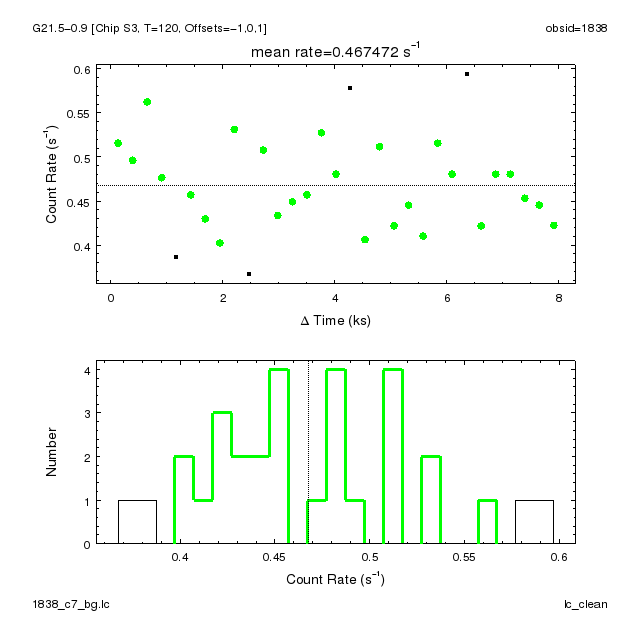

In [11]:
cat << EOM > c1.py
from lightcurves import *
lc_clean("1838_c7_bg.lc")
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png

Parameters used to clean the lightcurve are:
  script version = October 2016
  mean           = None
  clip           = 3
  scale          = 1.2
  minfrac        = 0.1
  outfile        = 1838_c7_bg.gti
  plot           = True
  rateaxis       = y
  color          = green
  pattern        = solid
  pattern color  = red

Total number of bins in lightcurve   = 31
Max length of one bin                = 255.997 s
Num. bins with a smaller exp. time   = 1
Num. bins with exp. time = 0         = 0
Calculated an initial mean (sigma-clipped) rate of 0.469276 ct/s
Lightcurve limits use a scale factor of 1.2 about this mean
Filtering lightcurve between rates of 0.391063 and 0.563131 ct/s
Number of good time bins = 27
Rate filter:  0.39106346801286157 <= count_rate < 0.56313139393852063 
Mean level of filtered lightcurve = 0.46747244416095812 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>0.39106346801286157 && count_rate<0.56313139393852063)

The corresponding times are:
  ((t

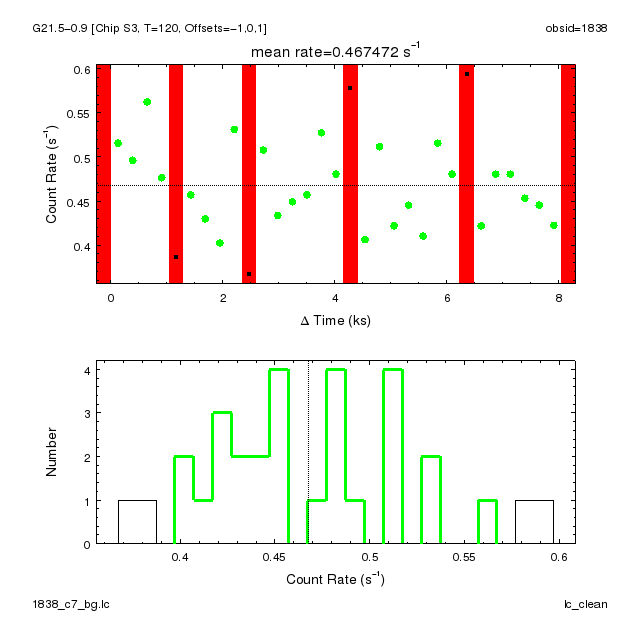

In [12]:
cat << EOM > c2.py
from lightcurves import *
lc_clean("1838_c7_bg.lc", outfile="1838_c7_bg.gti") 
print_window("chips_02.png","export.clobber=True")
quit()
EOM

chips -n c2.py
display < chips_02.png

## Running lc_clean via the deflare script

In [13]:
deflare 1838_c7_bg.lc 1838_c7_bg_deflare.gti method=clean

Parameters used to clean the lightcurve are:
  script version = October 2016
  mean           = None
  clip           = 3
  scale          = 1.2
  minfrac        = 0.1
  outfile        = 1838_c7_bg_deflare.gti
  plot           = False

Total number of bins in lightcurve   = 31
Max length of one bin                = 255.997 s
Num. bins with a smaller exp. time   = 1
Num. bins with exp. time = 0         = 0
Calculated an initial mean (sigma-clipped) rate of 0.469276 ct/s
Lightcurve limits use a scale factor of 1.2 about this mean
Filtering lightcurve between rates of 0.391063 and 0.563131 ct/s
Number of good time bins = 27
Rate filter:  0.39106346801286157 <= count_rate < 0.56313139393852063 
Mean level of filtered lightcurve = 0.46747244416095812 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>0.39106346801286157 && count_rate<0.56313139393852063)

The corresponding times are:
  ((time >= 84245789.155000001) && (time < 84246826.275000006)) ; 1.02 ksec, bin 1
  ((tim

## Filter event list

In [14]:
dmcopy "1838_c7.fits[@1838_c7_bg.gti]" 1838_c7_clean.fits clob+

In [15]:
dmkeypar 1838_c7.fits EXPOSURE echo+

7855.8988956987


In [16]:
dmkeypar 1838_c7_clean.fits EXPOSURE echo+

6828.7452726779


---
## Example of Strong Flare

In [18]:
dmcopy "1712/primary/acisf01712N004_evt2.fits.gz[energy=500:7000,ccd_id=7]" 1712_flare.fits clob+

In [19]:
cat << EOM > exclude.reg 
# Region file format: CIAO version 1.0
rotbox(4200.3328,4137.9892,1129.5056,74.07019,24.22333)
circle(4076.5,4088.5,316)
circle(4296.5,5024.5,48)
EOM

In [20]:
pset dmextract infile="1712_flare.fits[exclude sky=region(exclude.reg)][bin time=77379634.145:77407432.550:259.28]"
pset dmextract outfile=flare.lc
pset dmextract opt=ltc1
dmextract mode=h clob+


Parameters used to clean the lightcurve are:
  script version = October 2016
  mean           = None
  clip           = 3
  scale          = 1.2
  minfrac        = 0.1
  plot           = True
  rateaxis       = y
  color          = green

Total number of bins in lightcurve   = 108
Max length of one bin                = 255.997 s
Num. bins with a smaller exp. time   = 1
Num. bins with exp. time = 0         = 0
Calculated an initial mean (sigma-clipped) rate of 1.40627 ct/s
Lightcurve limits use a scale factor of 1.2 about this mean
Filtering lightcurve between rates of 1.17189 and 1.68752 ct/s
Number of good time bins = 2
Rate filter:  1.1718894631232735 <= count_rate < 1.6875208268975137 
Mean level of filtered lightcurve = 1.4062673557479282 ct/s

         1100.01357605 bins.
         Replacing with a width of 0.0110001 count/s
         This may indicate that the lightcurve contains strong flares that
         require manual filtering.

Fraction of bins that are good (0.0185185, 2 of 

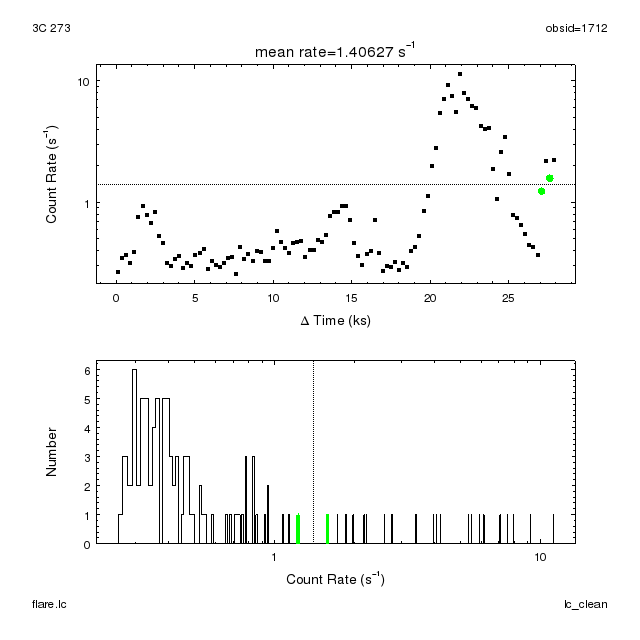

In [21]:
cat << EOM > c3.py
from lightcurves import *
try:
    lc_clean("flare.lc")
except Exception as e:
    print(e)
log_scale(X_AXIS)
log_scale("rate",Y_AXIS)
print_window("chips_03.png","export.clobber=True")
quit()
EOM

chips -n c3.py
display < chips_03.png

Parameters used to clean the lightcurve are:
  script version = October 2016
  mean           = 0.35
  clip           = 3
  scale          = 1.2
  minfrac        = 0.1
  outfile        = flare.gti
  plot           = True
  rateaxis       = y
  color          = green
  pattern        = solid
  pattern color  = red

Total number of bins in lightcurve   = 108
Max length of one bin                = 255.997 s
Num. bins with a smaller exp. time   = 1
Num. bins with exp. time = 0         = 0
Using a fixed mean rate of 0.35 ct/s
Lightcurve limits use a scale factor of 1.2 about this mean
Filtering lightcurve between rates of 0.291667 and 0.42 ct/s
Number of good time bins = 42
Rate filter:  0.2916666666666667 <= count_rate < 0.42 
Mean level of filtered lightcurve = 0.34914865433053721 ct/s

         1100.01357605 bins.
         Replacing with a width of 0.0110001 count/s
         This may indicate that the lightcurve contains strong flares that
         require manual filtering.

GTI limits c

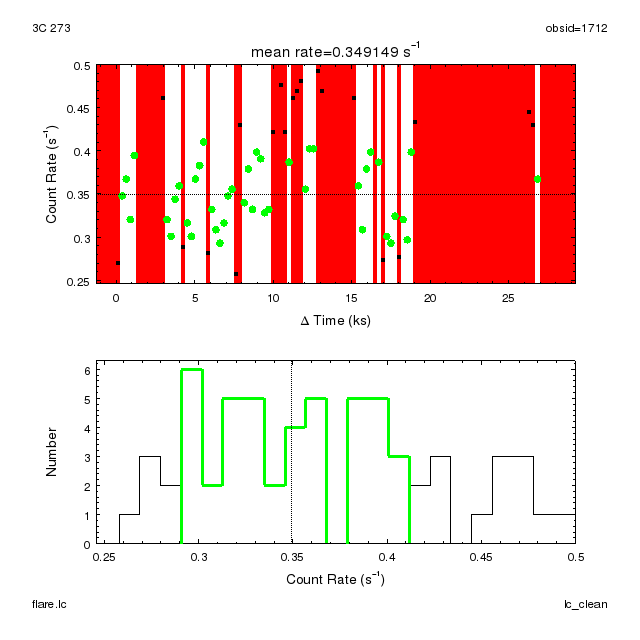

In [22]:
cat << EOM > c4.py
from lightcurves import *
try:
    lc_clean("flare.lc", mean=0.35, outfile="flare.gti")
except Exception as e:
    print(e)
limits(X_AXIS, AUTO, 0.5)
current_plot("rate")
limits(Y_AXIS, AUTO, 0.5)
print_window("chips_04.png","export.clobber=True")
quit()
EOM

chips -n c4.py
display < chips_04.png

# Cleanup


In [1]:
/bin/rm -rf 1712 1838 
